##STUDENT DROPOUT PREDICTION BY DR. TOCHUKWU BELONWU

In [ ]:
import pandas as pd

df = pd.read_csv('/content/student_dropout_dataset_v3.csv')

df.head(10)

,Student_ID,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout
0,1,22.1,Male,25000.0,Yes,3.36,86.1,2,20.4,Yes,No,5.5,0.96,0.90,0.90,Year 1,Arts,High School,0
1,2,20.7,Male,25000.0,Yes,4.30,68.0,2,44.0,No,No,6.8,1.28,1.20,1.19,Year 3,Engineering,Bachelor,1
2,3,22.4,Male,40183.0,Yes,4.40,70.9,0,48.9,Yes,No,5.5,1.68,1.32,1.32,Year 1,Arts,Master,0
3,4,24.4,Male,NaN,Yes,NaN,82.2,2,38.6,No,No,NaN,1.78,1.77,1.77,Year 1,CS,High School,1
4,5,20.5,Female,25319.0,Yes,4.19,75.7,1,23.0,No,No,7.0,1.48,0.91,0.87,Year 4,Business,Bachelor,0
5,6,20.5,Male,25000.0,Yes,4.11,89.1,2,47.1,No,Yes,6.0,2.52,2.72,2.69,Year 3,Business,NaN,0
6,7,24.5,Male,25000.0,Yes,3.00,78.2,1,37.4,Yes,Yes,7.3,0.64,0.33,0.44,Year 4,CS,Bachelor,0
7,8,22.7,Female,25000.0,Yes,2.12,86.4,1,34.0,No,Yes,6.5,1.79,1.14,1.14,Year 1,Arts,High School,0
8,9,20.0,Male,57413.0,Yes,4.07,97.5,3,52.1,No,No,4.2,3.08,2.81,2.81,Year 1,CS,High School,0
9,10,22.2,Female,44930.0,Yes,2.98,82.2,1,19.7,No,No,6.7,1.59,1.73,1.73,Year 1,Science,Master,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             10000 non-null  int64  
 1   Age                    10000 non-null  float64
 2   Gender                 10000 non-null  object 
 3   Family_Income          9500 non-null   float64
 4   Internet_Access        10000 non-null  object 
 5   Study_Hours_per_Day    9500 non-null   float64
 6   Attendance_Rate        10000 non-null  float64
 7   Assignment_Delay_Days  10000 non-null  int64  
 8   Travel_Time_Minutes    10000 non-null  float64
 9   Part_Time_Job          10000 non-null  object 
 10  Scholarship            10000 non-null  object 
 11  Stress_Index           9500 non-null   float64
 12  GPA                    10000 non-null  float64
 13  Semester_GPA           10000 non-null  float64
 14  CGPA                   10000 non-null  float64
 15  Sem

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')


In [ ]:
def basic_statistics(df):

    print("\n[PART 2] BASIC STATISTICS")
    print("-"*80)

    print("\n Numeric Features Summary:")
    print(df.describe().round(3))

    print("\n Data Types Distribution:")
    dtype_counts = df.dtypes.value_counts()
    print(dtype_counts)

    print(f"\n Memory Usage: {df.memory_usage().sum() / 1024**2:.2f} MB")


In [ ]:
basic_statistics(df)


[PART 2] BASIC STATISTICS
--------------------------------------------------------------------------------

 Numeric Features Summary:
       Student_ID        Age  Family_Income  Study_Hours_per_Day  \
count   10000.000  10000.000       9500.000             9500.000   
mean     5000.500     21.026      38377.247                4.015   
std      2886.896      2.140      20496.232                1.295   
min         1.000     17.000      25000.000                0.500   
25%      2500.750     19.500      25000.000                3.160   
50%      5000.500     21.000      29740.500                4.000   
75%      7500.250     22.500      44520.000                4.870   
max     10000.000     29.600     316601.000                8.980   

       Attendance_Rate  Assignment_Delay_Days  Travel_Time_Minutes  \
count        10000.000              10000.000            10000.000   
mean            81.737                  1.800               30.179   
std              8.221                  1

In [ ]:
def analyze_missing_values(df):
    """Comprehensive missing value analysis"""
    print("\n[PART 3] MISSING VALUE ANALYSIS")
    print("-"*80)

    missing_data = pd.DataFrame({
        'Column': df.columns,
        'Missing_Count': df.isnull().sum(),
        'Missing_Percentage': (df.isnull().sum() / len(df) * 100).round(2),
        'Data_Type': df.dtypes
    })

    missing_data = missing_data[missing_data['Missing_Count'] > 0].sort_values(
        'Missing_Percentage', ascending=False
    )

    if len(missing_data) == 0:
        print("\n✓ No missing values found!")
        return

    print("\n⚠️  Missing Values Summary:")
    print(missing_data.to_string(index=False))

    # Visualize missing values
    if len(missing_data) > 0:
        fig, ax = plt.subplots(figsize=(10, 6))
        missing_data_sorted = missing_data.sort_values('Missing_Percentage')
        ax.barh(missing_data_sorted['Column'], missing_data_sorted['Missing_Percentage'])
        ax.set_xlabel('Missing Percentage (%)')
        ax.set_title('Missing Values by Column')
        ax.grid(axis='x', alpha=0.3)
        plt.tight_layout()
        plt.savefig('01_missing_values.png', dpi=300, bbox_inches='tight')
        plt.show()


[PART 6] DISTRIBUTION ANALYSIS
--------------------------------------------------------------------------------

✓ Analyzing 12 numeric features

Skewness and Kurtosis Analysis:
               Column      Mean       Std  Skewness  Kurtosis
           Student_ID  5000.500  2886.896     0.000    -1.200
                  Age    21.026     2.140     0.183    -0.283
        Family_Income 38377.247 20496.232     2.827    13.889
  Study_Hours_per_Day     4.015     1.295     0.031    -0.014
      Attendance_Rate    81.737     8.221    -0.172     0.133
Assignment_Delay_Days     1.800     1.344     0.704     0.330
  Travel_Time_Minutes    30.179    11.919     0.094    -0.280
         Stress_Index     5.507     1.766    -0.008    -0.245
                  GPA     2.308     1.062    -0.198    -0.742
         Semester_GPA     2.300     1.074    -0.222    -0.801
                 CGPA     2.299     1.073    -0.225    -0.808
              Dropout     0.235     0.424     1.248    -0.444


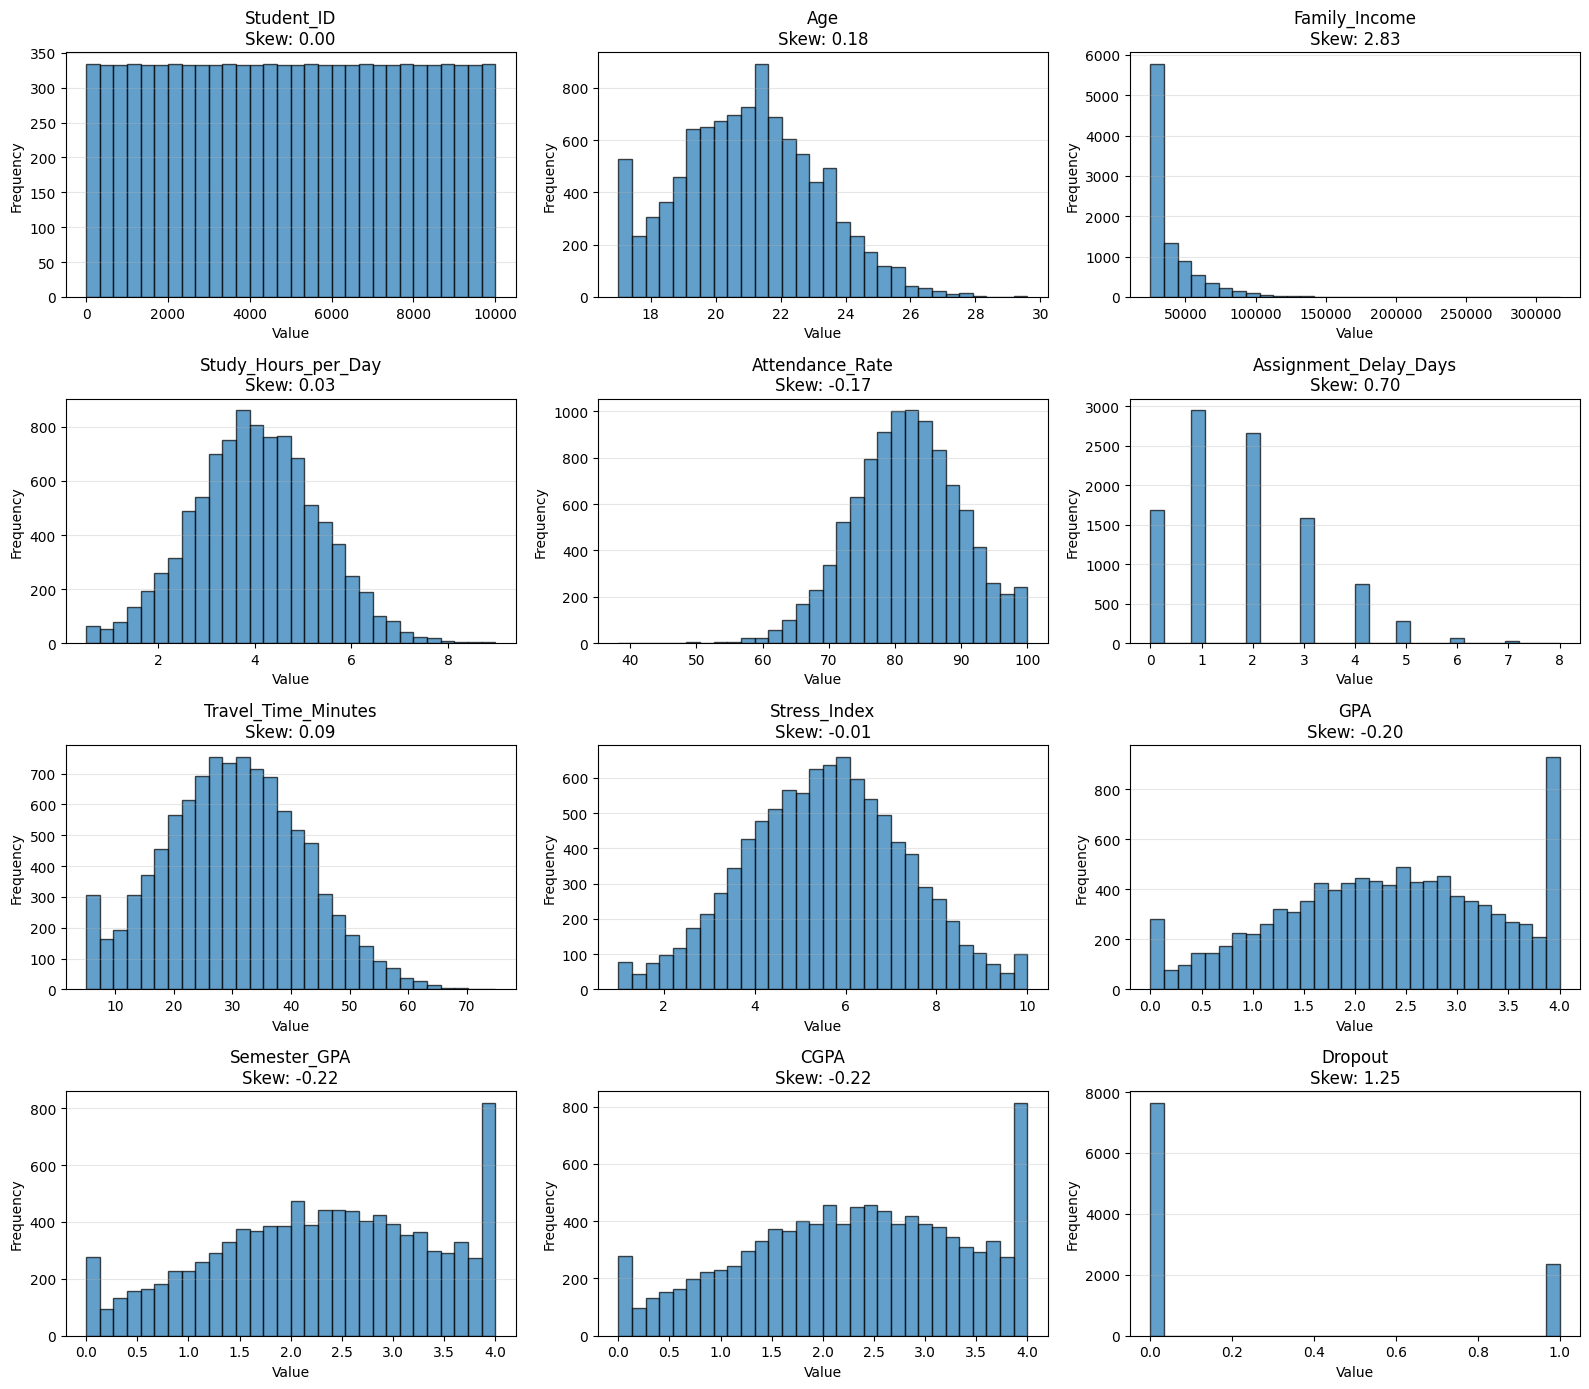


✓ Distribution plots saved


In [ ]:
analyze_distributions(df)

In [ ]:
def analyze_duplicates(df):
    """Analyze duplicate rows"""
    print("\n[PART 4] DUPLICATE ANALYSIS")
    print("-"*80)

    total_duplicates = df.duplicated().sum()
    print(f"\n✓ Total duplicate rows: {total_duplicates}")
    print(f"  Percentage: {total_duplicates/len(df)*100:.2f}%")

    if total_duplicates > 0:
        print(f"\n⚠️  Action: Remove duplicates during preprocessing")
    else:
        print(f"\n✓ No duplicates found!")

In [ ]:
analyze_duplicates(df)


[PART 4] DUPLICATE ANALYSIS
--------------------------------------------------------------------------------

✓ Total duplicate rows: 0
  Percentage: 0.00%

✓ No duplicates found!


In [ ]:
def analyze_outliers(df):
    """Identify outliers using IQR method"""
    print("\n[PART 5] OUTLIER ANALYSIS (Using IQR Method)")
    print("-"*80)

    numeric_cols = df.select_dtypes(include=[np.number]).columns

    outlier_summary = []

    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
        outlier_pct = (outliers / len(df) * 100) if len(df) > 0 else 0

        if outliers > 0:
            outlier_summary.append({
                'Column': col,
                'Outlier_Count': outliers,
                'Outlier_Percentage': outlier_pct,
                'Lower_Bound': lower_bound,
                'Upper_Bound': upper_bound
            })

    if outlier_summary:
        outlier_df = pd.DataFrame(outlier_summary)
        print("\n⚠️  Columns with Outliers:")
        print(outlier_df.to_string(index=False))


        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        axes = axes.ravel()

        for idx, col in enumerate(numeric_cols[:4]):
            axes[idx].boxplot(df[col].dropna())
            axes[idx].set_title(f'Boxplot: {col}')
            axes[idx].set_ylabel('Value')
            axes[idx].grid(axis='y', alpha=0.3)

        plt.tight_layout()
        plt.savefig('02_outliers_boxplot.png', dpi=300, bbox_inches='tight')
        plt.show()
    else:
        print("\n✓ No significant outliers detected")


[PART 5] OUTLIER ANALYSIS (Using IQR Method)
--------------------------------------------------------------------------------

⚠️  Columns with Outliers:
               Column  Outlier_Count  Outlier_Percentage  Lower_Bound  Upper_Bound
                  Age             33                0.33       15.000       27.000
        Family_Income            604                6.04    -4280.000    73800.000
  Study_Hours_per_Day             86                0.86        0.595        7.435
      Attendance_Rate             57                0.57       60.050      103.650
Assignment_Delay_Days             25                0.25       -2.000        6.000
  Travel_Time_Minutes             25                0.25       -2.850       63.150
              Dropout           2354               23.54        0.000        0.000


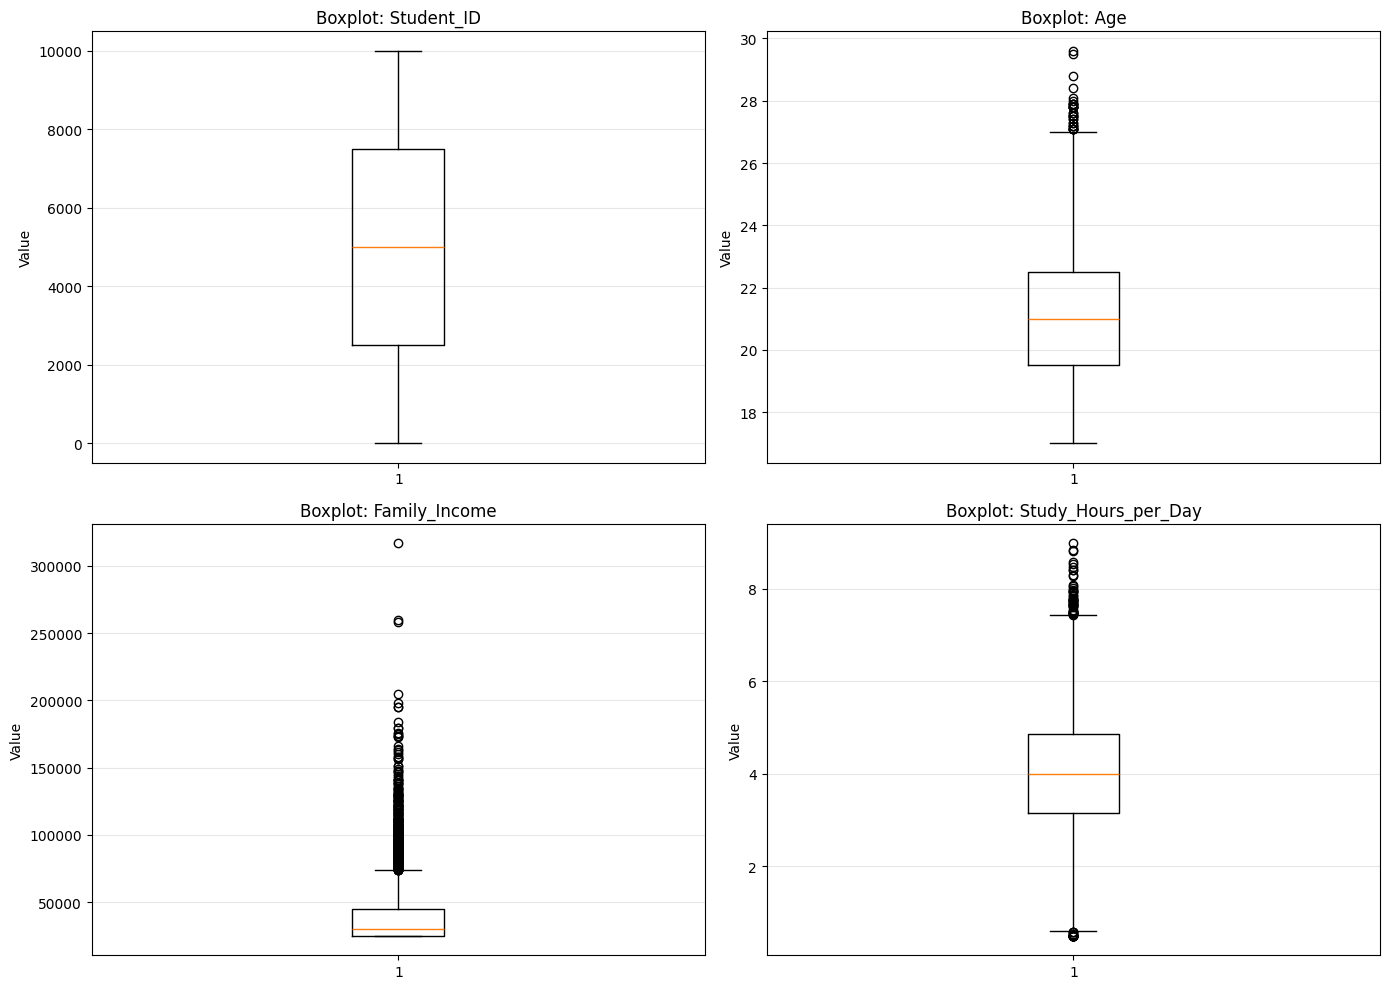

In [ ]:
analyze_outliers(df)

In [ ]:
def analyze_distributions(df):
    """Analyze distribution of numeric features"""
    print("\n[PART 6] DISTRIBUTION ANALYSIS")
    print("-"*80)

    numeric_cols = df.select_dtypes(include=[np.number]).columns
    print(f"\n✓ Analyzing {len(numeric_cols)} numeric features")

    # Skewness and Kurtosis
    print("\nSkewness and Kurtosis Analysis:")
    skew_kurt = pd.DataFrame({
        'Column': numeric_cols,
        'Mean': [df[col].mean() for col in numeric_cols],
        'Std': [df[col].std() for col in numeric_cols],
        'Skewness': [df[col].skew() for col in numeric_cols],
        'Kurtosis': [df[col].kurtosis() for col in numeric_cols]
    }).round(3)

    print(skew_kurt.to_string(index=False))

    # Visualize distributions
    fig, axes = plt.subplots(4, 3, figsize=(16, 14))
    axes = axes.ravel()

    for idx, col in enumerate(numeric_cols):
        if idx < len(axes):
            axes[idx].hist(df[col].dropna(), bins=30, edgecolor='black', alpha=0.7)
            axes[idx].set_title(f'{col}\nSkew: {df[col].skew():.2f}')
            axes[idx].set_xlabel('Value')
            axes[idx].set_ylabel('Frequency')
            axes[idx].grid(axis='y', alpha=0.3)

    # Hide unused subplots
    for idx in range(len(numeric_cols), len(axes)):
        axes[idx].axis('off')

    plt.tight_layout()
    plt.savefig('03_distributions.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("\n✓ Distribution plots saved")


[PART 6] DISTRIBUTION ANALYSIS
--------------------------------------------------------------------------------

✓ Analyzing 12 numeric features

Skewness and Kurtosis Analysis:
               Column      Mean       Std  Skewness  Kurtosis
           Student_ID  5000.500  2886.896     0.000    -1.200
                  Age    21.026     2.140     0.183    -0.283
        Family_Income 38377.247 20496.232     2.827    13.889
  Study_Hours_per_Day     4.015     1.295     0.031    -0.014
      Attendance_Rate    81.737     8.221    -0.172     0.133
Assignment_Delay_Days     1.800     1.344     0.704     0.330
  Travel_Time_Minutes    30.179    11.919     0.094    -0.280
         Stress_Index     5.507     1.766    -0.008    -0.245
                  GPA     2.308     1.062    -0.198    -0.742
         Semester_GPA     2.300     1.074    -0.222    -0.801
                 CGPA     2.299     1.073    -0.225    -0.808
              Dropout     0.235     0.424     1.248    -0.444


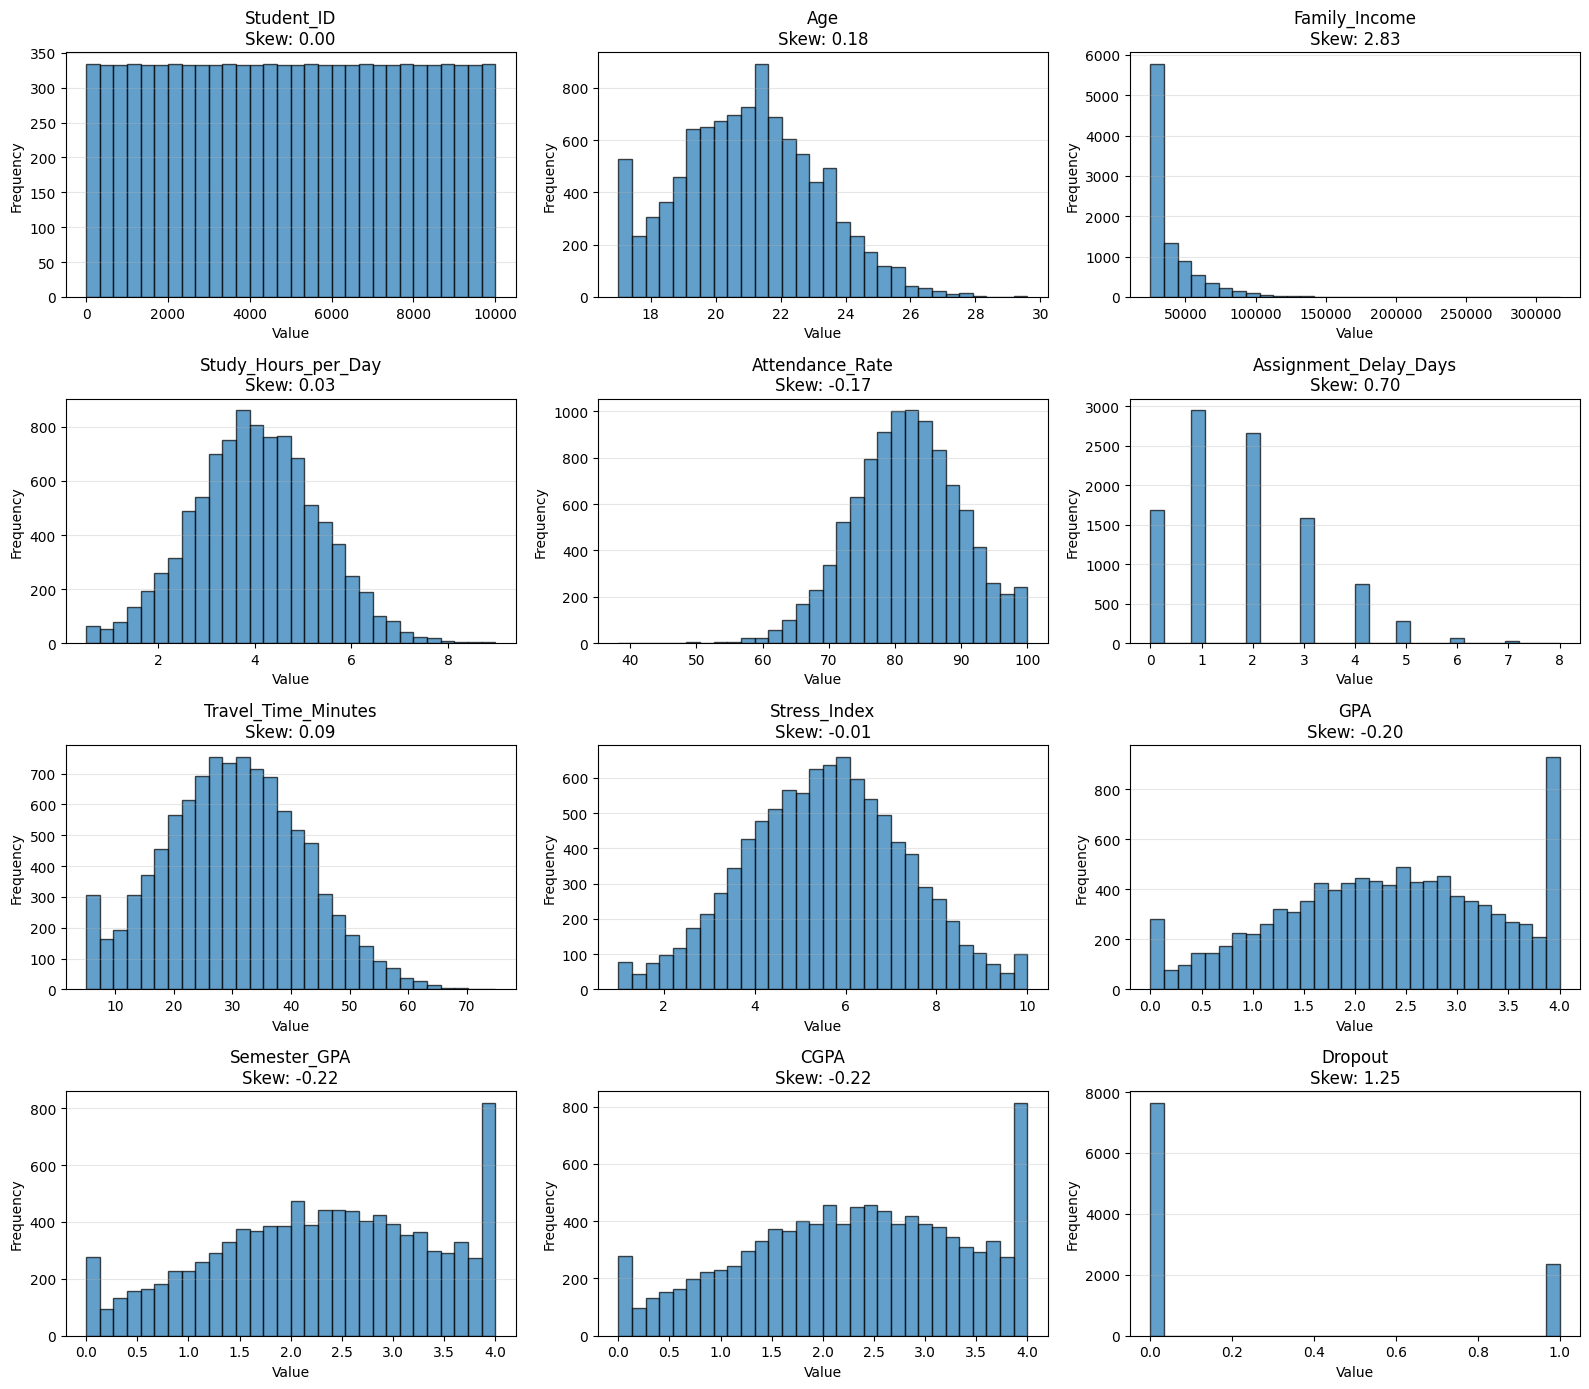


✓ Distribution plots saved


In [ ]:
analyze_distributions(df)

In [ ]:
def analyze_categorical_features(df):
    """Analyze categorical features"""
    print("\n[PART 7] CATEGORICAL FEATURES ANALYSIS")
    print("-"*80)

    categorical_cols = df.select_dtypes(include=['object']).columns

    if len(categorical_cols) == 0:
        print("\n✓ No categorical features found")
        return

    print(f"\n✓ Analyzing {len(categorical_cols)} categorical features")

    for col in categorical_cols:
        print(f"\n📊 {col}:")
        print(f"   Unique values: {df[col].nunique()}")
        print(f"   Value counts:")
        print(df[col].value_counts().to_string())

    # Visualize categorical features
    n_cols = len(categorical_cols)
    fig, axes = plt.subplots((n_cols + 1) // 2, 2, figsize=(14, 4 * ((n_cols + 1) // 2)))

    if n_cols == 1:
        axes = [axes]
    else:
        axes = axes.ravel()

    for idx, col in enumerate(categorical_cols):
        df[col].value_counts().plot(kind='bar', ax=axes[idx], color='steelblue')
        axes[idx].set_title(f'{col}')
        axes[idx].set_ylabel('Count')
        axes[idx].tick_params(axis='x', rotation=45)

    # Hide unused subplots
    for idx in range(len(categorical_cols), len(axes)):
        axes[idx].axis('off')

    plt.tight_layout()
    plt.savefig('04_categorical_features.png', dpi=300, bbox_inches='tight')
    plt.show()



[PART 7] CATEGORICAL FEATURES ANALYSIS
--------------------------------------------------------------------------------

✓ Analyzing 7 categorical features

📊 Gender:
   Unique values: 2
   Value counts:
Gender
Female    5011
Male      4989

📊 Internet_Access:
   Unique values: 2
   Value counts:
Internet_Access
Yes    8769
No     1231

📊 Part_Time_Job:
   Unique values: 2
   Value counts:
Part_Time_Job
No     5996
Yes    4004

📊 Scholarship:
   Unique values: 2
   Value counts:
Scholarship
No     6489
Yes    3511

📊 Semester:
   Unique values: 4
   Value counts:
Semester
Year 4    2536
Year 3    2521
Year 2    2488
Year 1    2455

📊 Department:
   Unique values: 5
   Value counts:
Department
Science        2061
Arts           2026
Business       2002
CS             1974
Engineering    1937

📊 Parental_Education:
   Unique values: 4
   Value counts:
Parental_Education
Bachelor       3949
High School    3072
Master         2003
PhD             465


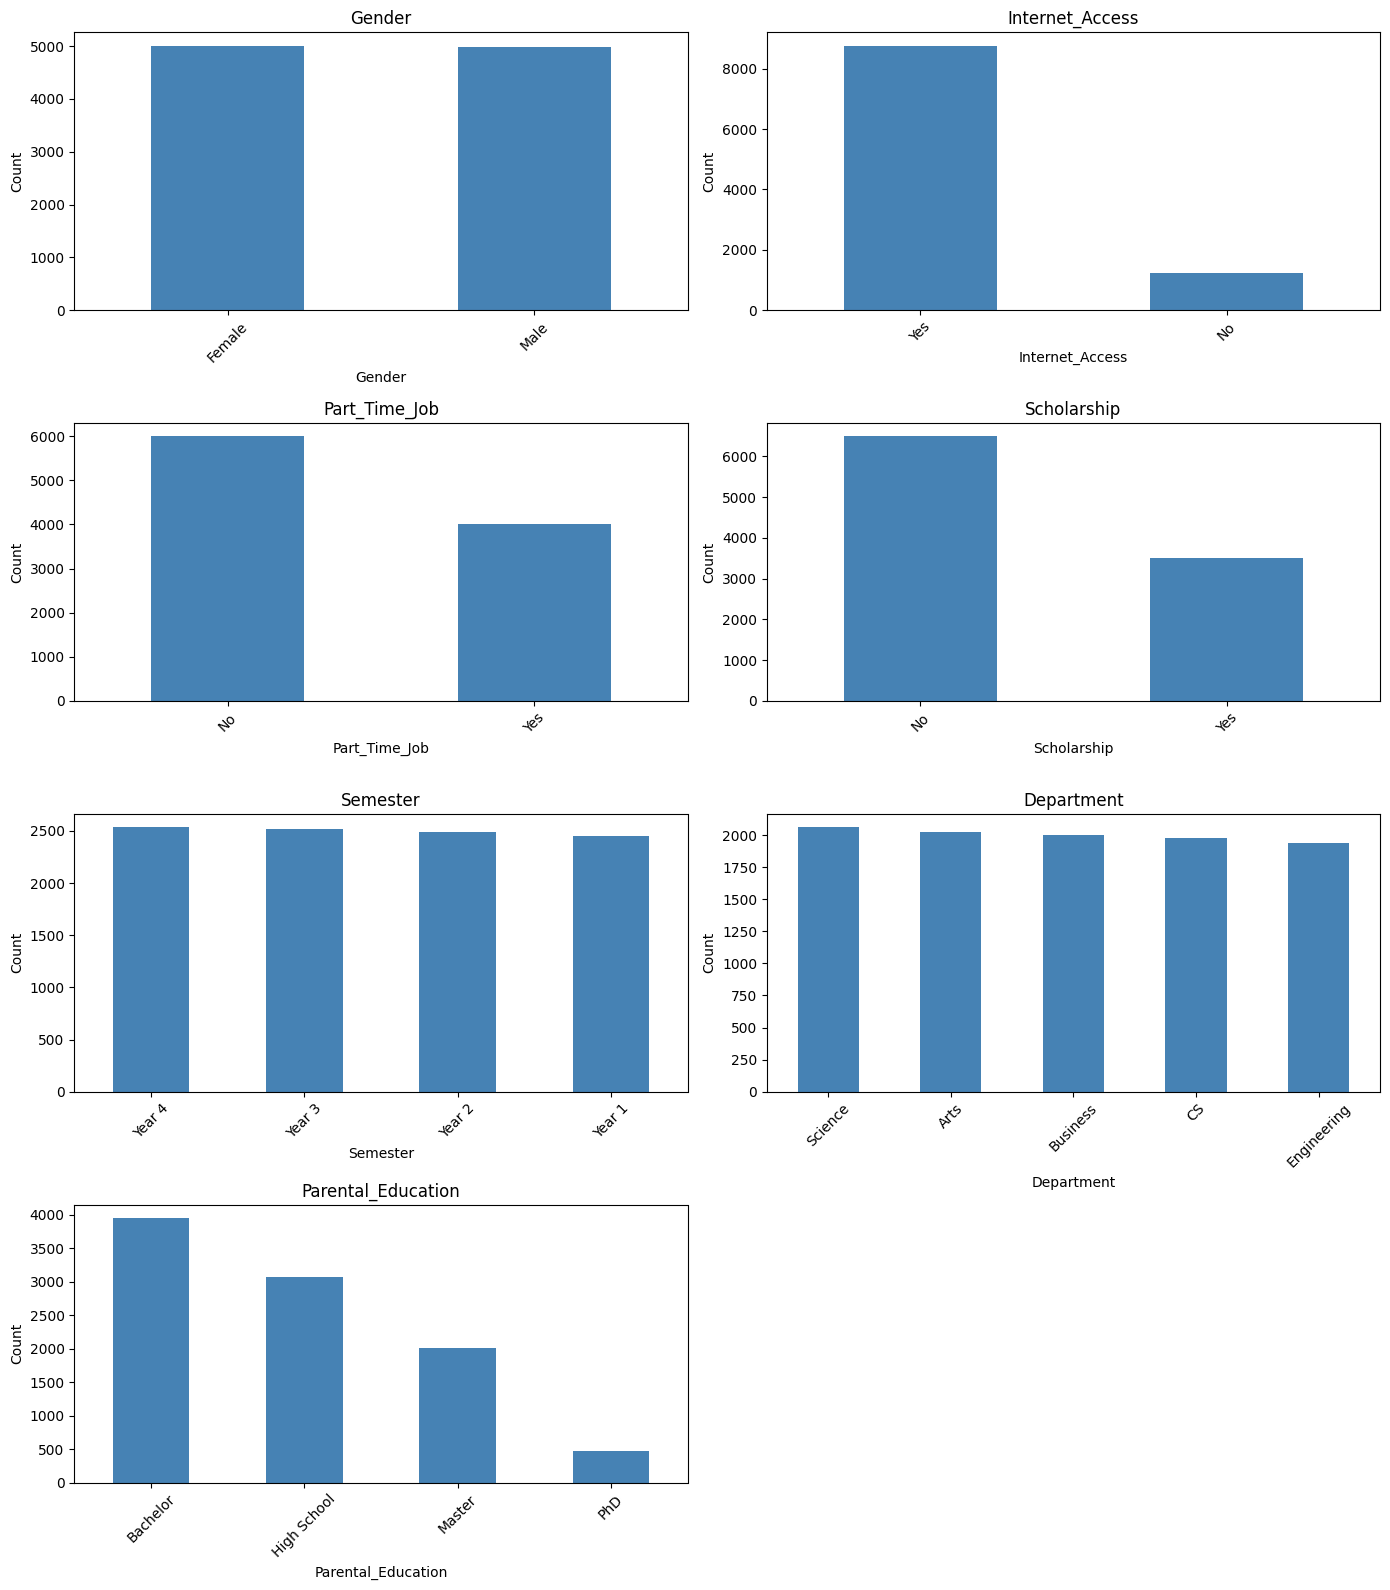

In [ ]:
analyze_categorical_features(df)

In [ ]:
def analyze_target_variable(df, target='Dropout'):
    """Detailed target variable analysis"""
    print("\n[PART 8] TARGET VARIABLE ANALYSIS")
    print("-"*80)

    if target not in df.columns:
        print(f"\n Target column '{target}' not found!")
        return

    target_counts = df[target].value_counts()
    target_pct = (df[target].value_counts(normalize=True) * 100).round(2)

    print(f"\n✓ Target Variable: {target}")
    print(f"\nClass Distribution:")
    print(f"   Class 0 (No Dropout): {target_counts[0]} ({target_pct[0]}%)")
    print(f"   Class 1 (Dropout):    {target_counts[1]} ({target_pct[1]}%)")

    # Calculate imbalance ratio
    if 0 in target_counts and 1 in target_counts:
        imbalance_ratio = target_counts[0] / target_counts[1]
        print(f"\n  Imbalance Ratio: {imbalance_ratio:.2f}:1")

        if imbalance_ratio > 3:
            print(f"     SEVERE IMBALANCE - SMOTE balancing HIGHLY RECOMMENDED")
        elif imbalance_ratio > 2:
            print(f"    MODERATE IMBALANCE - Consider SMOTE balancing")
        else:
            print(f"   ✓ Acceptable balance - but SMOTE still recommended")

    # Visualize target distribution
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    target_counts.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'])
    axes[0].set_title('Target Variable Distribution')
    axes[0].set_ylabel('Count')
    axes[0].set_xticklabels(['No Dropout', 'Dropout'], rotation=0)
    axes[0].grid(axis='y', alpha=0.3)

    target_pct.plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
                    colors=['#2ecc71', '#e74c3c'])
    axes[1].set_title('Target Variable Percentage')
    axes[1].set_ylabel('')

    plt.tight_layout()
    plt.savefig('05_target_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()


[PART 8] TARGET VARIABLE ANALYSIS
--------------------------------------------------------------------------------

✓ Target Variable: Dropout

Class Distribution:
   Class 0 (No Dropout): 7646 (76.46%)
   Class 1 (Dropout):    2354 (23.54%)

⚠️  Imbalance Ratio: 3.25:1
   ⚠️  SEVERE IMBALANCE - SMOTE balancing HIGHLY RECOMMENDED


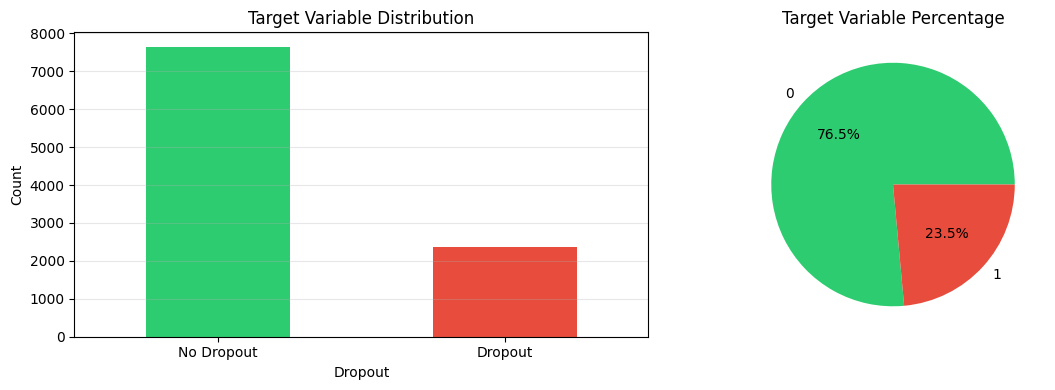

In [ ]:
analyze_target_variable(df)

In [ ]:
def analyze_correlations(df, target='Dropout'):
    """Correlation analysis with target variable"""
    print("\n[PART 9] CORRELATION ANALYSIS")
    print("-"*80)

    if target not in df.columns:
        print(f"\n  Target column '{target}' not found!")
        return

    numeric_cols = df.select_dtypes(include=[np.number]).columns
    numeric_df = df[numeric_cols].copy()

    # Correlation with target
    if target in numeric_df.columns:
        correlations = numeric_df.corr()[target].sort_values(ascending=False)

        print(f"\n✓ Correlation with {target}:")
        print(correlations.round(3).to_string())

        # Visualize correlation with target
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))

        # Correlation bars
        correlations.drop(target).plot(kind='barh', ax=axes[0], color='steelblue')
        axes[0].set_title(f'Feature Correlation with {target}')
        axes[0].set_xlabel('Correlation Coefficient')
        axes[0].grid(axis='x', alpha=0.3)

        # Correlation heatmap
        corr_matrix = numeric_df.corr()
        sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
                   center=0, ax=axes[1], cbar_kws={'label': 'Correlation'})
        axes[1].set_title('Feature Correlation Matrix')

        plt.tight_layout()
        plt.savefig('06_correlation_analysis.png', dpi=300, bbox_inches='tight')
        plt.show()

        print("\n✓ Correlation plots saved")


[PART 9] CORRELATION ANALYSIS
--------------------------------------------------------------------------------

✓ Correlation with Dropout:
Dropout                  1.000
Stress_Index             0.256
Assignment_Delay_Days    0.082
Travel_Time_Minutes      0.028
Age                      0.008
Student_ID               0.007
Family_Income           -0.011
Study_Hours_per_Day     -0.089
Attendance_Rate         -0.164
CGPA                    -0.445
Semester_GPA            -0.445
GPA                     -0.460


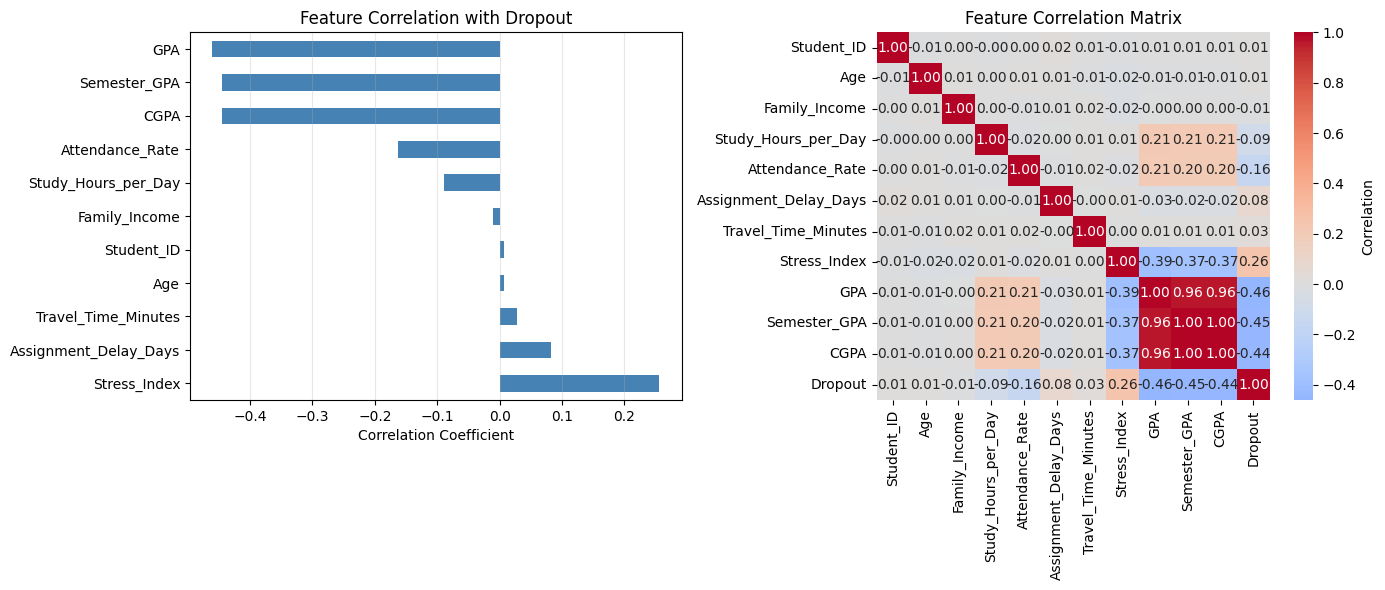


✓ Correlation plots saved


In [ ]:
analyze_correlations(df)

In [ ]:
def analyze_feature_target_relationships(df, target='Dropout'):
    """Analyze relationships between features and target"""
    print("\n[PART 10] FEATURE-TARGET RELATIONSHIPS")
    print("-"*80)

    if target not in df.columns:
        print(f"\n Target column '{target}' not found!")
        return

    numeric_cols = df.select_dtypes(include=[np.number]).columns
    numeric_cols = [col for col in numeric_cols if col != target]

    print(f"\n✓ Analyzing {len(numeric_cols)} features vs {target}")

    # Statistical tests
    print("\nStatistical Comparison by Target Class:")
    print("(Using t-test to check if means differ between classes)")

    comparison_data = []
    for col in numeric_cols:
        class_0 = df[df[target] == 0][col].dropna()
        class_1 = df[df[target] == 1][col].dropna()

        if len(class_0) > 0 and len(class_1) > 0:
            t_stat, p_value = stats.ttest_ind(class_0, class_1)

            comparison_data.append({
                'Feature': col,
                'Class_0_Mean': class_0.mean(),
                'Class_1_Mean': class_1.mean(),
                'Difference': class_1.mean() - class_0.mean(),
                'P_Value': p_value,
                'Significant': '✓' if p_value < 0.05 else '✗'
            })

    comparison_df = pd.DataFrame(comparison_data).sort_values('P_Value')
    print(comparison_df.to_string(index=False))

    # Visualize feature-target relationships
    n_features = min(6, len(numeric_cols))
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.ravel()

    for idx, col in enumerate(numeric_cols[:n_features]):
        df.boxplot(column=col, by=target, ax=axes[idx])
        axes[idx].set_title(f'{col} by {target}')
        axes[idx].set_xlabel(target)
        axes[idx].set_ylabel(col)
        plt.sca(axes[idx])
        plt.xticks([1, 2], ['No', 'Yes'])

    plt.suptitle('Feature Distributions by Target Class', fontsize=14, y=1.00)
    plt.tight_layout()
    plt.savefig('07_feature_target_relationships.png', dpi=300, bbox_inches='tight')
    plt.show()


[PART 10] FEATURE-TARGET RELATIONSHIPS
--------------------------------------------------------------------------------

✓ Analyzing 11 features vs Dropout

Statistical Comparison by Target Class:
(Using t-test to check if means differ between classes)
              Feature  Class_0_Mean  Class_1_Mean  Difference       P_Value Significant
         Semester_GPA      2.565566      1.437659   -1.127907  0.000000e+00           ✓
                 CGPA      2.563462      1.438989   -1.124473  0.000000e+00           ✓
                  GPA      2.579623      1.427613   -1.152011  0.000000e+00           ✓
         Stress_Index      5.256316      6.319634    1.063318 1.269026e-141           ✓
      Attendance_Rate     82.482775     79.313934   -3.168842  6.786878e-61           ✓
  Study_Hours_per_Day      4.078920      3.806220   -0.272700  2.600256e-18           ✓
Assignment_Delay_Days      1.738295      1.999150    0.260856  1.641843e-16           ✓
  Travel_Time_Minutes     29.993565     30

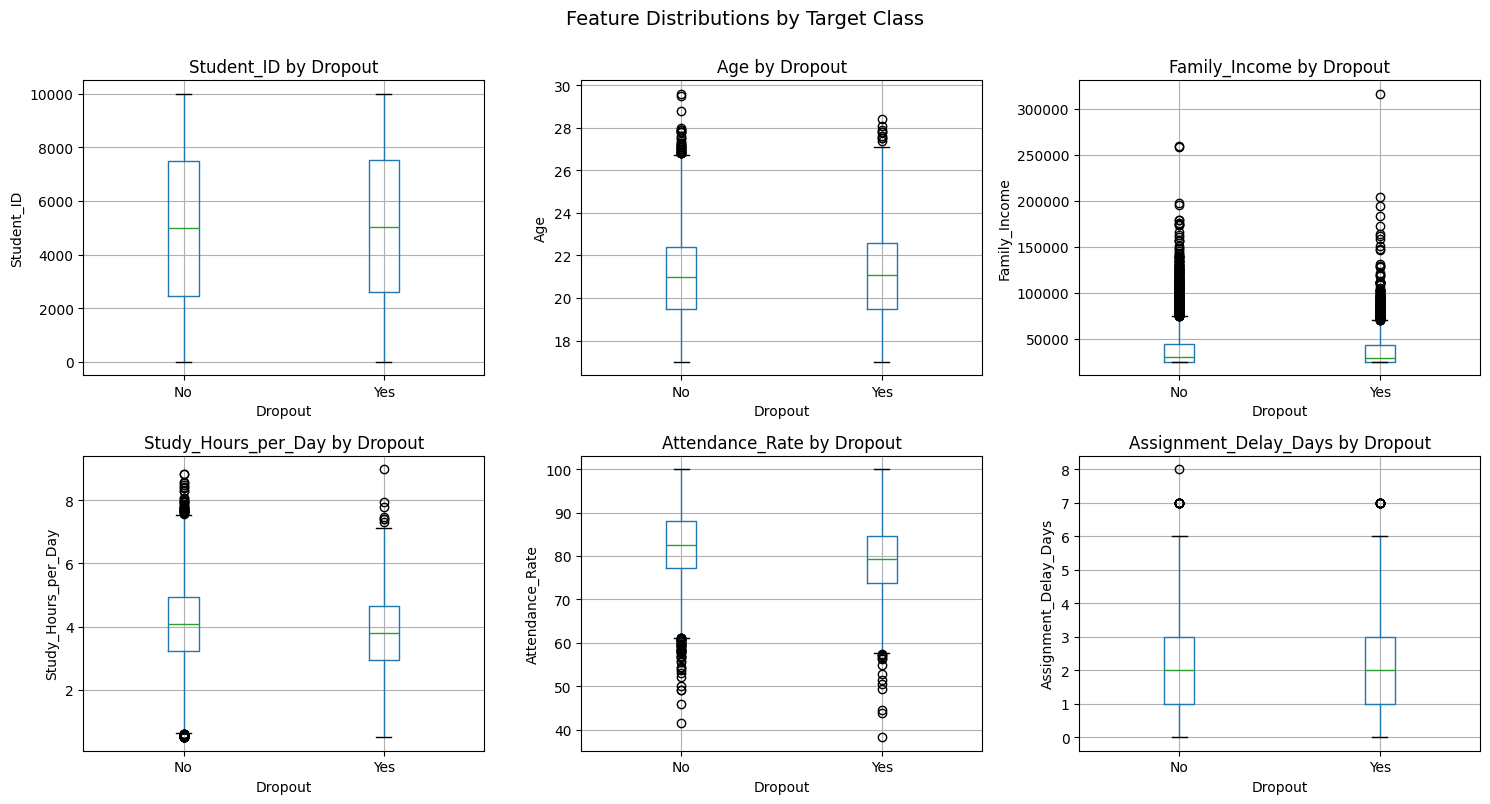

In [ ]:
analyze_feature_target_relationships(df)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             10000 non-null  int64  
 1   Age                    10000 non-null  float64
 2   Gender                 10000 non-null  object 
 3   Family_Income          9500 non-null   float64
 4   Internet_Access        10000 non-null  object 
 5   Study_Hours_per_Day    9500 non-null   float64
 6   Attendance_Rate        10000 non-null  float64
 7   Assignment_Delay_Days  10000 non-null  int64  
 8   Travel_Time_Minutes    10000 non-null  float64
 9   Part_Time_Job          10000 non-null  object 
 10  Scholarship            10000 non-null  object 
 11  Stress_Index           9500 non-null   float64
 12  GPA                    10000 non-null  float64
 13  Semester_GPA           10000 non-null  float64
 14  CGPA                   10000 non-null  float64
 15  Sem

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_curve, auc,
    roc_auc_score, f1_score, precision_score, recall_score,
    precision_recall_curve, accuracy_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import warnings
warnings.filterwarnings('ignore')


np.random.seed(42)
tf.random.set_seed(42)

print("=" * 80)
print("STUDENT DROPOUT PREDICTION MODEL - COMPREHENSIVE ANALYSIS")
print("=" * 80)

STUDENT DROPOUT PREDICTION MODEL - COMPREHENSIVE ANALYSIS


In [ ]:
def preprocess_data(df):

    df = df.copy()

    print("="*80)
    print("DATA PREPROCESSING")
    print("="*80)


    print("\n[STEP 1] Removing duplicate rows...")
    initial_rows = len(df)
    df = df.drop_duplicates()
    duplicates_removed = initial_rows - len(df)
    print(f"  ✓ Removed {duplicates_removed} duplicate rows")


    print("\n[STEP 2] Analyzing missing values...")
    missing_before = df.isnull().sum()
    missing_before = missing_before[missing_before > 0].sort_values(ascending=False)

    if len(missing_before) > 0:
        print("\n    Missing values detected:")
        for col, count in missing_before.items():
            percentage = (count / len(df) * 100)
            print(f"     • {col}: {count} missing ({percentage:.2f}%)")
    else:
        print("  No missing values found")


    print("\n[STEP 3] Handling missing values...")


    print("\n  [A] Numerical Features → Median Imputation")
    print("      (Robust to outliers, preserves distribution)")

    numerical_cols = df.select_dtypes(include=[np.number]).columns
    numerical_missing = []

    for col in numerical_cols:
        if df[col].isnull().sum() > 0:
            missing_count = df[col].isnull().sum()
            median_value = df[col].median()
            df[col].fillna(median_value, inplace=True)
            numerical_missing.append((col, missing_count, median_value))
            print(f"      ✓ {col}: {missing_count} values → Median: {median_value:.2f}")

    if not numerical_missing:
        print("      ✓ No missing values in numerical features")


    print("\n  [B] Categorical Features → Mode Imputation")
    print("      (Most frequent category)")

    categorical_cols = df.select_dtypes(include=['object']).columns
    categorical_missing = []

    for col in categorical_cols:
        if df[col].isnull().sum() > 0:
            missing_count = df[col].isnull().sum()
            mode_value = df[col].mode()[0]
            df[col].fillna(mode_value, inplace=True)
            categorical_missing.append((col, missing_count, mode_value))
            print(f" {col}: {missing_count} values → Mode: '{mode_value}'")

    if not categorical_missing:
        print("  No missing values in categorical features")


    print("\n[STEP 4] Verifying missing value handling...")
    missing_after = df.isnull().sum()
    missing_after = missing_after[missing_after > 0]

    if len(missing_after) == 0:
        print("   SUCCESS! All missing values have been handled.")
        print(f"   Total records preserved: {len(df)} students")
        print(f"   Data completeness: 100%")
    else:
        print("    WARNING! Some missing values remain:")
        for col, count in missing_after.items():
            print(f"     • {col}: {count} missing")


    print("\n[STEP 5] Preparing features and target...")

    target = 'Dropout'
    if target not in df.columns:
        raise ValueError(f"Target column '{target}' not found in dataset")


    X = df.drop([target, 'Student_ID'], axis=1, errors='ignore')
    y = df[target]

    print(f"  ✓ Target variable: {target}")
    print(f"  ✓ Features: {X.shape[1]}")
    print(f"  ✓ Samples: {X.shape[0]}")


    print("\n[STEP 6] Encoding categorical variables...")

    categorical_features = X.select_dtypes(include=['object']).columns
    label_encoders = {}

    if len(categorical_features) > 0:
        for col in categorical_features:
            le = LabelEncoder()
            X[col] = le.fit_transform(X[col])
            label_encoders[col] = le
            print(f"  ✓ {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")
    else:
        print("  ✓ No categorical features to encode (all already encoded)")

    print("\n" + "="*80)
    print("PREPROCESSING COMPLETE!")
    print("="*80)

    return X, y, label_encoders


X, y, label_encoders = preprocess_data(df)
print(f"\nProcessed features shape: {X.shape}")
print(f"Target variable shape: {y.shape}")

DATA PREPROCESSING

[STEP 1] Removing duplicate rows...
  ✓ Removed 0 duplicate rows

[STEP 2] Analyzing missing values...

  ⚠️  Missing values detected:
     • Parental_Education: 511 missing (5.11%)
     • Family_Income: 500 missing (5.00%)
     • Study_Hours_per_Day: 500 missing (5.00%)
     • Stress_Index: 500 missing (5.00%)

[STEP 3] Handling missing values...

  [A] Numerical Features → Median Imputation
      (Robust to outliers, preserves distribution)
      ✓ Family_Income: 500 values → Median: 29740.50
      ✓ Study_Hours_per_Day: 500 values → Median: 4.00
      ✓ Stress_Index: 500 values → Median: 5.50

  [B] Categorical Features → Mode Imputation
      (Most frequent category)
      ✓ Parental_Education: 511 values → Mode: 'Bachelor'

[STEP 4] Verifying missing value handling...
  ✓ SUCCESS! All missing values have been handled.
  ✓ Total records preserved: 10000 students
  ✓ Data completeness: 100%

[STEP 5] Preparing features and target...
  ✓ Target variable: Dropout
 

In [ ]:
preprocess_data(df)

DATA PREPROCESSING

[STEP 1] Removing duplicate rows...
  ✓ Removed 0 duplicate rows

[STEP 2] Analyzing missing values...

  ⚠️  Missing values detected:
     • Parental_Education: 511 missing (5.11%)
     • Family_Income: 500 missing (5.00%)
     • Study_Hours_per_Day: 500 missing (5.00%)
     • Stress_Index: 500 missing (5.00%)

[STEP 3] Handling missing values...

  [A] Numerical Features → Median Imputation
      (Robust to outliers, preserves distribution)
      ✓ Family_Income: 500 values → Median: 29740.50
      ✓ Study_Hours_per_Day: 500 values → Median: 4.00
      ✓ Stress_Index: 500 values → Median: 5.50

  [B] Categorical Features → Mode Imputation
      (Most frequent category)
      ✓ Parental_Education: 511 values → Mode: 'Bachelor'

[STEP 4] Verifying missing value handling...
  ✓ SUCCESS! All missing values have been handled.
  ✓ Total records preserved: 10000 students
  ✓ Data completeness: 100%

[STEP 5] Preparing features and target...
  ✓ Target variable: Dropout
 

(       Age  Gender  Family_Income  Internet_Access  Study_Hours_per_Day  \
 0     22.1       1        25000.0                1                 3.36   
 1     20.7       1        25000.0                1                 4.30   
 2     22.4       1        40183.0                1                 4.40   
 3     24.4       1        29740.5                1                 4.00   
 4     20.5       0        25319.0                1                 4.19   
 ...    ...     ...            ...              ...                  ...   
 9995  23.9       0        42286.0                0                 4.62   
 9996  17.0       0        61103.0                1                 2.87   
 9997  19.4       1        25000.0                1                 4.73   
 9998  22.1       0        40302.0                1                 5.85   
 9999  22.4       0        76796.0                1                 4.95   
 
       Attendance_Rate  Assignment_Delay_Days  Travel_Time_Minutes  \
 0              

In [ ]:
print(X.head(10))

    Age  Gender  Family_Income  Internet_Access  Study_Hours_per_Day  \
0  22.1       1        25000.0                1                 3.36   
1  20.7       1        25000.0                1                 4.30   
2  22.4       1        40183.0                1                 4.40   
3  24.4       1        29740.5                1                 4.00   
4  20.5       0        25319.0                1                 4.19   
5  20.5       1        25000.0                1                 4.11   
6  24.5       1        25000.0                1                 3.00   
7  22.7       0        25000.0                1                 2.12   
8  20.0       1        57413.0                1                 4.07   
9  22.2       0        44930.0                1                 2.98   

   Attendance_Rate  Assignment_Delay_Days  Travel_Time_Minutes  Part_Time_Job  \
0             86.1                      2                 20.4              1   
1             68.0                      2    

In [ ]:
def analyze_class_balance(y, title=""):

    class_distribution = y.value_counts()
    class_percentage = (y.value_counts(normalize=True) * 100).round(2)

    print(f"\nClass Distribution {title}:")
    print(f"  Class 0 (No Dropout): {class_distribution[0]} ({class_percentage[0]}%)")
    print(f"  Class 1 (Dropout): {class_distribution[1]} ({class_percentage[1]}%)")
    print(f"  Imbalance Ratio: {class_distribution[0] / class_distribution[1]:.2f}:1")


    fig, axes = plt.subplots(1, 2, figsize=(12, 4))


    y.value_counts().plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'])
    axes[0].set_title(f'Class Distribution {title}')
    axes[0].set_ylabel('Count')
    axes[0].set_xticklabels(['No Dropout (0)', 'Dropout (1)'], rotation=0)


    y.value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
                          colors=['#2ecc71', '#e74c3c'])
    axes[1].set_title(f'Class Distribution Percentage {title}')
    axes[1].set_ylabel('')

    plt.tight_layout()
    return fig


Class Distribution Student Dropout:
  Class 0 (No Dropout): 7646 (76.46%)
  Class 1 (Dropout): 2354 (23.54%)
  Imbalance Ratio: 3.25:1


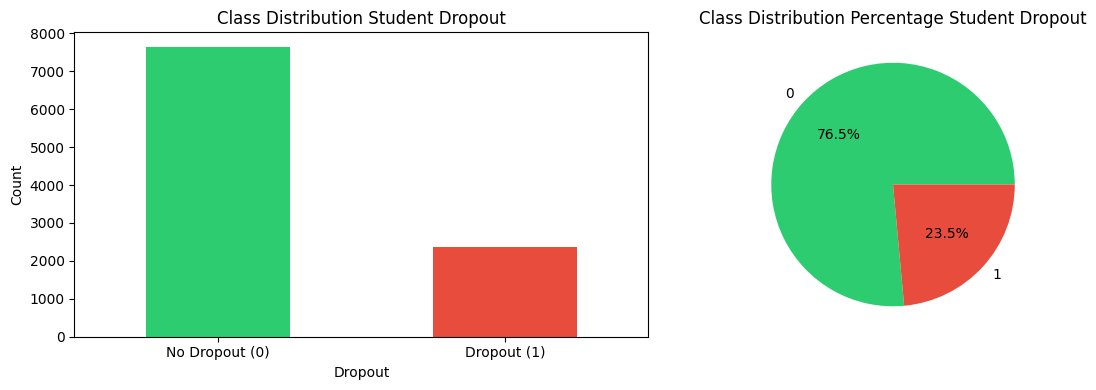

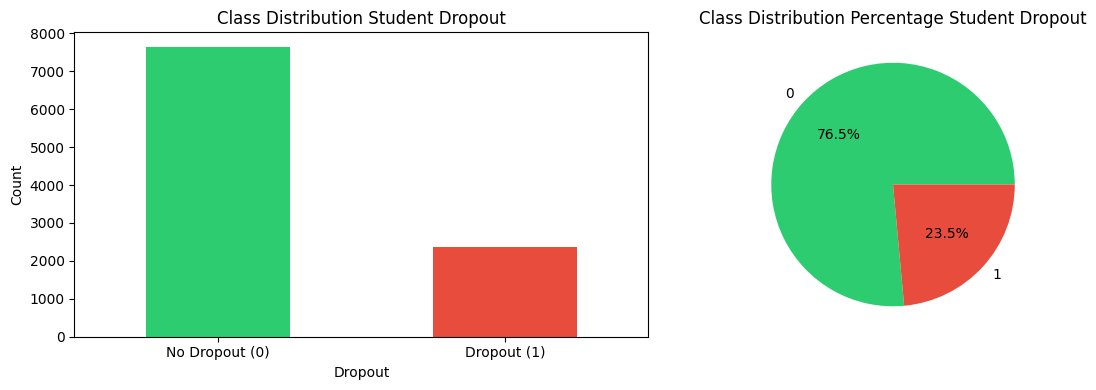

In [ ]:
analyze_class_balance(y, title="Student Dropout")

In [ ]:
print("FEATURE SCALING AND DATA SPLITTING")
print("-" * 80)

def prepare_data(X, y):


    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    print(f"Training set size: {X_train.shape[0]} samples")
    print(f"Test set size: {X_test.shape[0]} samples")
    print(f"Training set class distribution:")
    print(f"  No Dropout: {(y_train == 0).sum()} ({(y_train == 0).sum()/len(y_train)*100:.1f}%)")
    print(f"  Dropout: {(y_train == 1).sum()} ({(y_train == 1).sum()/len(y_train)*100:.1f}%)")


    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    return X_train_scaled, X_test_scaled, y_train, y_test, scaler

FEATURE SCALING AND DATA SPLITTING
--------------------------------------------------------------------------------


In [ ]:
prepare_data(X,y)

Training set size: 8000 samples
Test set size: 2000 samples
Training set class distribution:
  No Dropout: 6117 (76.5%)
  Dropout: 1883 (23.5%)


(array([[-0.61306463, -0.99875078, -0.38766249, ...,  1.33995733,
          0.69387242,  1.27263629],
        [ 0.32168995, -0.99875078,  1.66715896, ...,  0.44080797,
         -0.00833876,  0.1649124 ],
        [ 0.69559178, -0.99875078,  0.78589637, ...,  1.33995733,
          1.3960836 ,  0.1649124 ],
        ...,
        [ 1.16296907,  1.00125078, -0.64074404, ...,  1.33995733,
          1.3960836 , -0.9428115 ],
        [ 0.88254269, -0.99875078, -0.59452137, ..., -0.45834139,
         -0.71054994, -0.9428115 ],
        [-1.87498331,  1.00125078,  1.08375925, ...,  0.44080797,
          1.3960836 , -0.9428115 ]]),
 array([[-0.75327782, -0.99875078,  3.59007183, ..., -1.35749074,
          0.69387242,  1.27263629],
        [ 1.67708408,  1.00125078,  2.20408748, ..., -1.35749074,
         -1.41276112, -0.9428115 ],
        [ 0.18147676,  1.00125078, -0.64074404, ..., -1.35749074,
         -0.00833876,  1.27263629],
        ...,
        [-0.14568734, -0.99875078, -0.64074404, ...,  

In [ ]:
print("APPLYING SMOTE FOR DATA BALANCING")
print("-" * 80)

def apply_smote(X_train, y_train):

    smote = SMOTE(random_state=42)
    X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

    print(f"Training set size after SMOTE: {X_train_smote.shape[0]} samples")
    print(f"Training set class distribution after SMOTE:")
    print(f"  No Dropout: {(y_train_smote == 0).sum()}")
    print(f"  Dropout: {(y_train_smote == 1).sum()}")

    return X_train_smote, y_train_smote

APPLYING SMOTE FOR DATA BALANCING
--------------------------------------------------------------------------------


In [ ]:
print("\n[STEP 6] DEFINING MODELS")
print("-" * 80)

def get_models():

    models = {
        'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
        'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
        'XGBoost': XGBClassifier(n_estimators=100, random_state=42, verbosity=0)
    }
    return models

def create_neural_network(input_dim):

    model = keras.Sequential([
        layers.Dense(128, activation='relu', input_shape=(input_dim,)),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy', keras.metrics.AUC()]
    )

    return model

print("Models Defined:")
print("  1. Logistic Regression")
print("  2. Random Forest (100 trees)")
print("  3. XGBoost (100 trees)")
print("  4. Neural Network (4 layers with dropout)")


[STEP 6] DEFINING MODELS
--------------------------------------------------------------------------------
Models Defined:
  1. Logistic Regression
  2. Random Forest (100 trees)
  3. XGBoost (100 trees)
  4. Neural Network (4 layers with dropout)


In [ ]:
print("\n[STEP 7] DEFINING EVALUATION METRICS")
print("-" * 80)

def evaluate_model(y_true, y_pred, y_pred_proba, model_name, dataset_type):

    print(f"\n{'='*60}")
    print(f"Model: {model_name} | Dataset: {dataset_type}")
    print(f"{'='*60}")


    accuracy = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_pred_proba)

    print(f"\nPerformance Metrics:")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  F1 Score:  {f1:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  ROC AUC:   {roc_auc:.4f}")


    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    print(f"\nConfusion Matrix:")
    print(f"  True Negatives:  {tn}")
    print(f"  False Positives: {fp}")
    print(f"  False Negatives: {fn}")
    print(f"  True Positives:  {tp}")


    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0

    print(f"\nAdditional Metrics:")
    print(f"  Sensitivity (Recall): {sensitivity:.4f}")
    print(f"  Specificity:          {specificity:.4f}")

    # Classification Report
    print(f"\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=['No Dropout', 'Dropout']))

    return {
        'accuracy': accuracy,
        'f1_score': f1,
        'precision': precision,
        'recall': recall,
        'roc_auc': roc_auc,
        'specificity': specificity,
        'sensitivity': sensitivity,
        'cm': cm,
        'y_pred_proba': y_pred_proba
    }



[STEP 7] DEFINING EVALUATION METRICS
--------------------------------------------------------------------------------


In [ ]:
print("\n[STEP 8] FEATURE IMPORTANCE ANALYSIS FUNCTION")
print("-" * 80)

def plot_feature_importance(model, feature_names, model_name, top_n=15):

    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
        indices = np.argsort(importances)[-top_n:]

        fig, ax = plt.subplots(figsize=(10, 6))
        ax.barh(range(len(indices)), importances[indices], color='steelblue')
        ax.set_yticks(range(len(indices)))
        ax.set_yticklabels([feature_names[i] for i in indices])
        ax.set_xlabel('Importance')
        ax.set_title(f'Feature Importance - {model_name}')
        plt.tight_layout()
        return fig
    else:
        print(f"{model_name} does not support feature importance")
        return None


[STEP 8] FEATURE IMPORTANCE ANALYSIS FUNCTION
--------------------------------------------------------------------------------


In [ ]:
def plot_roc_curves(results_dict, dataset_type):

    fig, ax = plt.subplots(figsize=(10, 8))

    for model_name, results in results_dict.items():
        fpr, tpr, _ = roc_curve(results['y_true'], results['y_pred_proba'])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, label=f"{model_name} (AUC = {roc_auc:.4f})", linewidth=2)

    ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'ROC Curves - {dataset_type} Dataset')
    ax.legend(loc='lower right')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    return fig

In [ ]:
def plot_confusion_matrices(results_dict, dataset_type):

    n_models = len(results_dict)
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.ravel()

    for idx, (model_name, results) in enumerate(results_dict.items()):
        cm = results['cm']
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                   cbar=False, xticklabels=['No Dropout', 'Dropout'],
                   yticklabels=['No Dropout', 'Dropout'])
        axes[idx].set_title(f'{model_name} - {dataset_type}')
        axes[idx].set_ylabel('True Label')
        axes[idx].set_xlabel('Predicted Label')

    if n_models < 4:
        fig.delaxes(axes[n_models])

    plt.tight_layout()
    return fig

In [ ]:
def create_results_comparison(unbalanced_results, balanced_results):

    comparison_data = []

    for model_name in unbalanced_results.keys():
        unbal = unbalanced_results[model_name]
        bal = balanced_results[model_name]

        comparison_data.append({
            'Model': model_name,
            'Dataset': 'Unbalanced',
            'Accuracy': f"{unbal['accuracy']:.4f}",
            'F1 Score': f"{unbal['f1_score']:.4f}",
            'Precision': f"{unbal['precision']:.4f}",
            'Recall': f"{unbal['recall']:.4f}",
            'ROC AUC': f"{unbal['roc_auc']:.4f}",
            'Specificity': f"{unbal['specificity']:.4f}"
        })

        comparison_data.append({
            'Model': model_name,
            'Dataset': 'Balanced (SMOTE)',
            'Accuracy': f"{bal['accuracy']:.4f}",
            'F1 Score': f"{bal['f1_score']:.4f}",
            'Precision': f"{bal['precision']:.4f}",
            'Recall': f"{bal['recall']:.4f}",
            'ROC AUC': f"{bal['roc_auc']:.4f}",
            'Specificity': f"{bal['specificity']:.4f}"
        })

    comparison_df = pd.DataFrame(comparison_data)
    return comparison_df



[ANALYZING] Original class distribution...

Class Distribution (Original Dataset):
  Class 0 (No Dropout): 7646 (76.46%)
  Class 1 (Dropout): 2354 (23.54%)
  Imbalance Ratio: 3.25:1


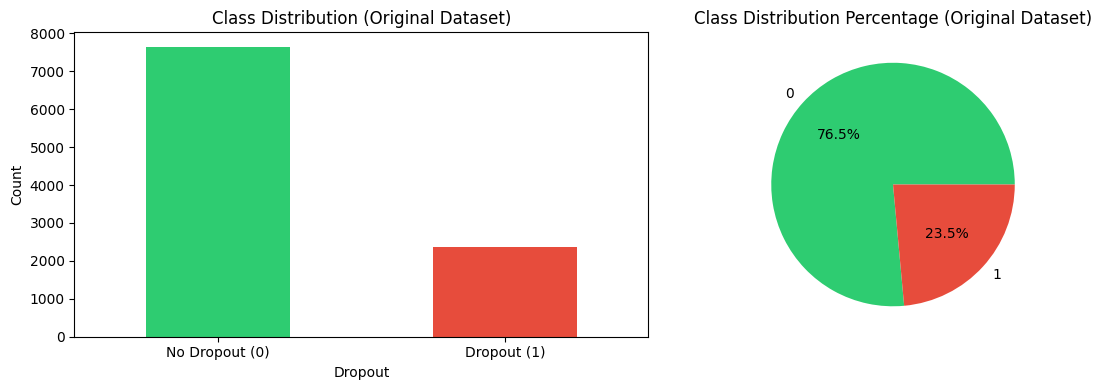

✓ Class balance visualization saved


In [ ]:
print("\n[ANALYZING] Original class distribution...")
fig_balance = analyze_class_balance(y, title="(Original Dataset)")
plt.savefig('class_balance_original.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Class balance visualization saved")

In [ ]:
print("\n" + "█"*80)
print("█ PHASE 3: DATA SPLITTING & SCALING")
print("█"*80)
X_train_unbal, X_test, y_train_unbal, y_test, scaler = prepare_data(X, y)


████████████████████████████████████████████████████████████████████████████████
█ PHASE 3: DATA SPLITTING & SCALING
████████████████████████████████████████████████████████████████████████████████
Training set size: 8000 samples
Test set size: 2000 samples
Training set class distribution:
  No Dropout: 6117 (76.5%)
  Dropout: 1883 (23.5%)


In [ ]:
print("\n" + "█"*80)
print("█ PHASE 4: SMOTE BALANCING")
print("█"*80)
X_train_bal, y_train_bal = apply_smote(X_train_unbal, y_train_unbal)


████████████████████████████████████████████████████████████████████████████████
█ PHASE 4: SMOTE BALANCING
████████████████████████████████████████████████████████████████████████████████
Training set size after SMOTE: 12234 samples
Training set class distribution after SMOTE:
  No Dropout: 6117
  Dropout: 6117


In [ ]:
models = get_models()
neural_net = create_neural_network(X_train_unbal.shape[1])

In [ ]:
print("\n" + "█"*80)
print("█ PHASE 5: TRAINING ON UNBALANCED DATA")
print("█"*80)
unbalanced_results = {}

for model_name, model in models.items():
    print(f"\n[TRAINING] {model_name}...")
    model.fit(X_train_unbal, y_train_unbal)
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    results = evaluate_model(y_test, y_pred, y_pred_proba, model_name, 'UNBALANCED')
    results['model'] = model
    results['y_true'] = y_test
    unbalanced_results[model_name] = results

# Train neural network on unbalanced data
print(f"\n[TRAINING] Neural Network (UNBALANCED)...")
history_unbal = neural_net.fit(
    X_train_unbal, y_train_unbal,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)
y_pred_nn_unbal = (neural_net.predict(X_test) > 0.5).astype(int).ravel()
y_pred_proba_nn_unbal = neural_net.predict(X_test).ravel()

results_nn_unbal = evaluate_model(y_test, y_pred_nn_unbal, y_pred_proba_nn_unbal,
                                  'Neural Network', 'UNBALANCED')
results_nn_unbal['model'] = neural_net
results_nn_unbal['y_true'] = y_test
unbalanced_results['Neural Network'] = results_nn_unbal




████████████████████████████████████████████████████████████████████████████████
█ PHASE 5: TRAINING ON UNBALANCED DATA
████████████████████████████████████████████████████████████████████████████████

[TRAINING] Logistic Regression...

Model: Logistic Regression | Dataset: UNBALANCED

Performance Metrics:
  Accuracy:  0.8120
  F1 Score:  0.5000
  Precision: 0.6690
  Recall:    0.3992
  ROC AUC:   0.8206

Confusion Matrix:
  True Negatives:  1436
  False Positives: 93
  False Negatives: 283
  True Positives:  188

Additional Metrics:
  Sensitivity (Recall): 0.3992
  Specificity:          0.9392

Classification Report:
              precision    recall  f1-score   support

  No Dropout       0.84      0.94      0.88      1529
     Dropout       0.67      0.40      0.50       471

    accuracy                           0.81      2000
   macro avg       0.75      0.67      0.69      2000
weighted avg       0.80      0.81      0.79      2000


[TRAINING] Random Forest...

Model: Random Fo

In [ ]:
print("\n" + "█"*80)
print("█ PHASE 6: TRAINING ON BALANCED DATA (SMOTE)")
print("█"*80)
balanced_results = {}

# Reinitialize models for balanced training
models_balanced = get_models()
neural_net_balanced = create_neural_network(X_train_bal.shape[1])

for model_name, model in models_balanced.items():
    print(f"\n[TRAINING] {model_name} (SMOTE-balanced)...")
    model.fit(X_train_bal, y_train_bal)
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    results = evaluate_model(y_test, y_pred, y_pred_proba, model_name, 'BALANCED (SMOTE)')
    results['model'] = model
    results['y_true'] = y_test
    balanced_results[model_name] = results

# Train neural network on balanced data
print(f"\n[TRAINING] Neural Network (SMOTE-balanced)...")
history_bal = neural_net_balanced.fit(
    X_train_bal, y_train_bal,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)
y_pred_nn_bal = (neural_net_balanced.predict(X_test) > 0.5).astype(int).ravel()
y_pred_proba_nn_bal = neural_net_balanced.predict(X_test).ravel()

results_nn_bal = evaluate_model(y_test, y_pred_nn_bal, y_pred_proba_nn_bal,
                                'Neural Network', 'BALANCED (SMOTE)')
results_nn_bal['model'] = neural_net_balanced
results_nn_bal['y_true'] = y_test
balanced_results['Neural Network'] = results_nn_bal


████████████████████████████████████████████████████████████████████████████████
█ PHASE 6: TRAINING ON BALANCED DATA (SMOTE)
████████████████████████████████████████████████████████████████████████████████

[TRAINING] Logistic Regression (SMOTE-balanced)...

Model: Logistic Regression | Dataset: BALANCED (SMOTE)

Performance Metrics:
  Accuracy:  0.7420
  F1 Score:  0.5791
  Precision: 0.4702
  Recall:    0.7537
  ROC AUC:   0.8188

Confusion Matrix:
  True Negatives:  1129
  False Positives: 400
  False Negatives: 116
  True Positives:  355

Additional Metrics:
  Sensitivity (Recall): 0.7537
  Specificity:          0.7384

Classification Report:
              precision    recall  f1-score   support

  No Dropout       0.91      0.74      0.81      1529
     Dropout       0.47      0.75      0.58       471

    accuracy                           0.74      2000
   macro avg       0.69      0.75      0.70      2000
weighted avg       0.80      0.74      0.76      2000


[TRAINING] Rand


████████████████████████████████████████████████████████████████████████████████
█ PHASE 7: FEATURE IMPORTANCE ANALYSIS
████████████████████████████████████████████████████████████████████████████████

[ANALYZING] Random Forest & XGBoost (Unbalanced)...


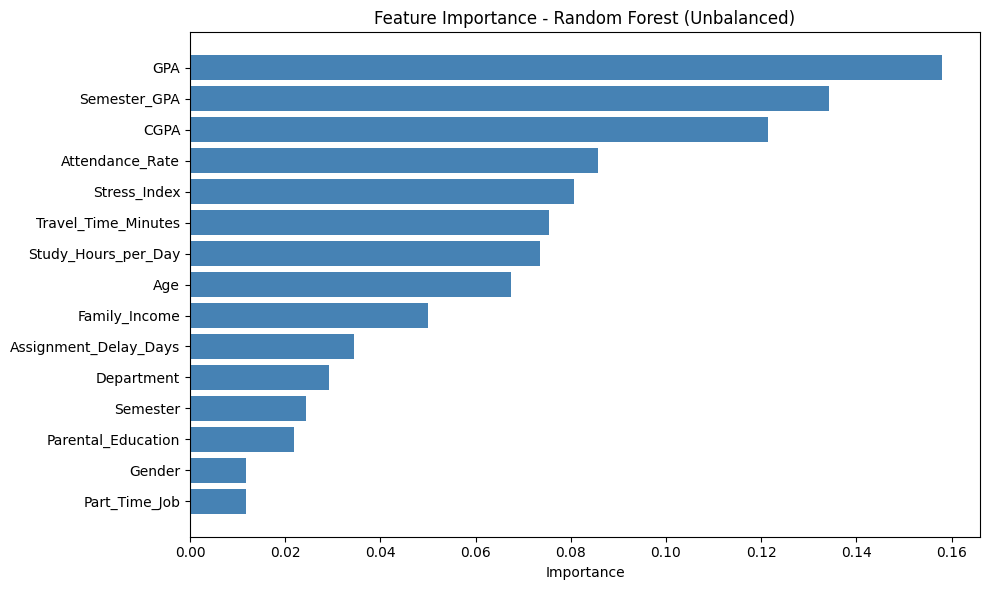

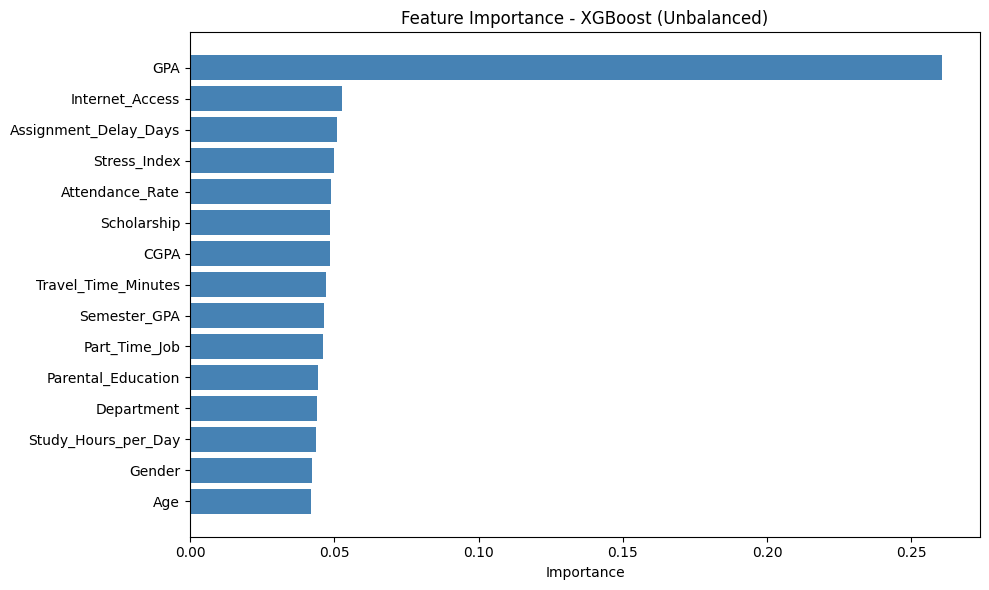


[ANALYZING] Random Forest & XGBoost (Balanced)...


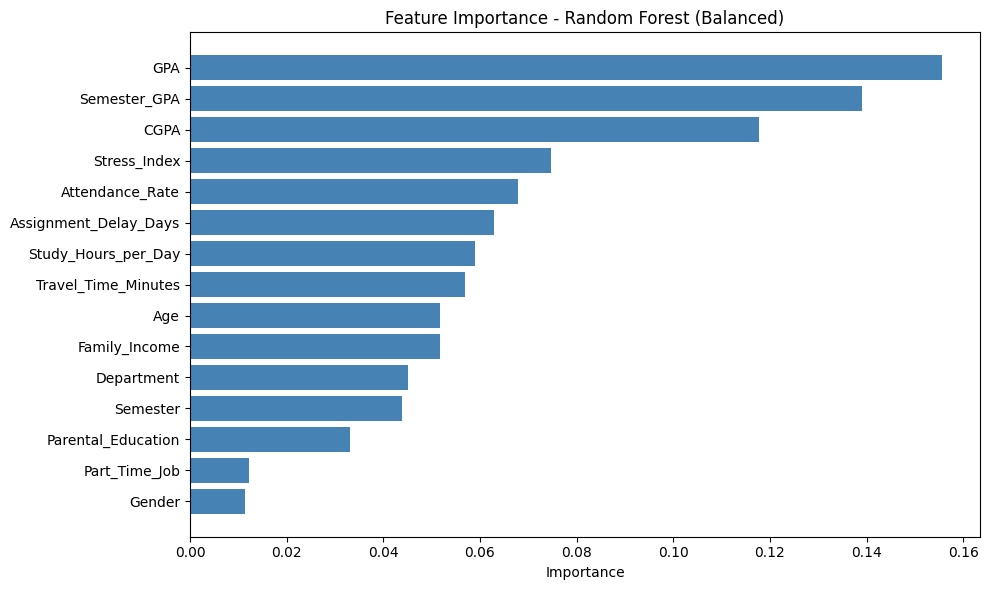

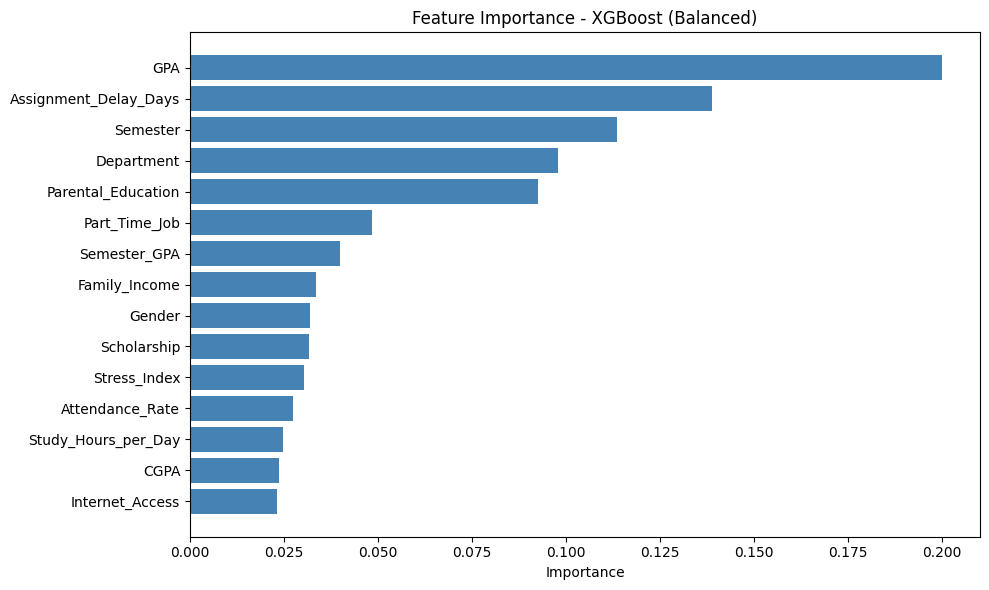

In [ ]:
print("\n" + "█"*80)
print("█ PHASE 7: FEATURE IMPORTANCE ANALYSIS")
print("█"*80)
feature_names = X.columns.tolist()

print("\n[ANALYZING] Random Forest & XGBoost (Unbalanced)...")
for model_name in ['Random Forest', 'XGBoost']:
    fig = plot_feature_importance(unbalanced_results[model_name]['model'],
                                  feature_names, f"{model_name} (Unbalanced)")
    if fig:
        plt.savefig(f'feature_importance_{model_name.lower()}_unbalanced.png',
                    dpi=300, bbox_inches='tight')
        plt.show()

print("\n[ANALYZING] Random Forest & XGBoost (Balanced)...")
for model_name in ['Random Forest', 'XGBoost']:
    fig = plot_feature_importance(balanced_results[model_name]['model'],
                                  feature_names, f"{model_name} (Balanced)")
    if fig:
        plt.savefig(f'feature_importance_{model_name.lower()}_balanced.png',
                    dpi=300, bbox_inches='tight')
        plt.show()


[PLOTTING] ROC Curves...


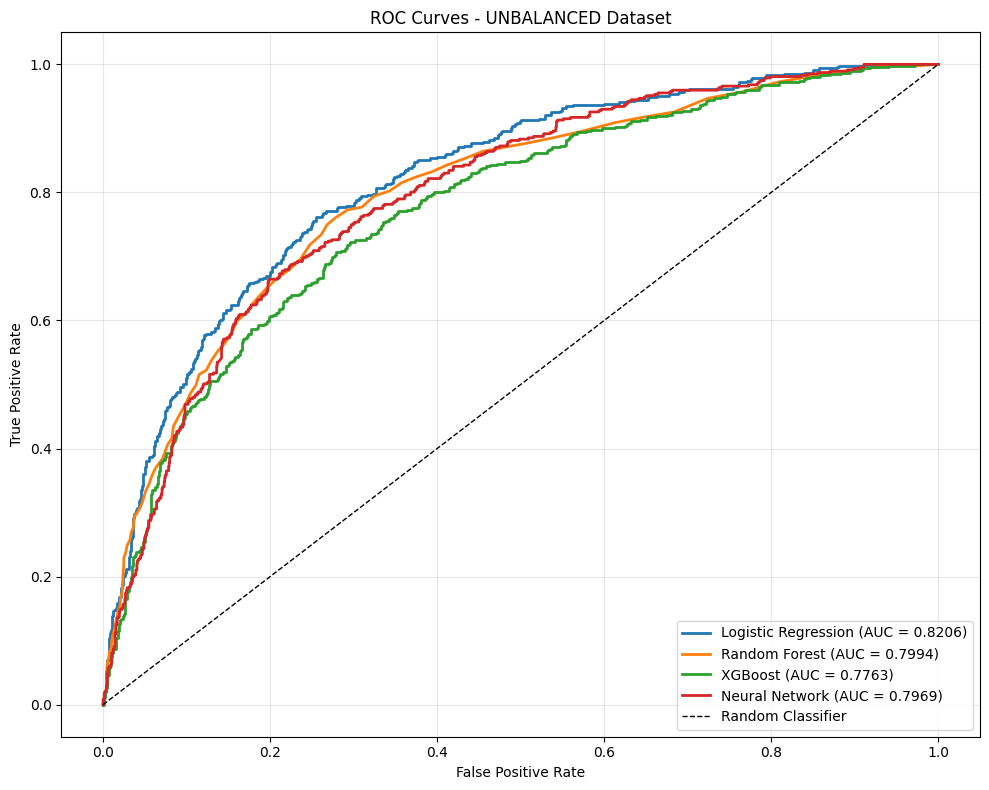

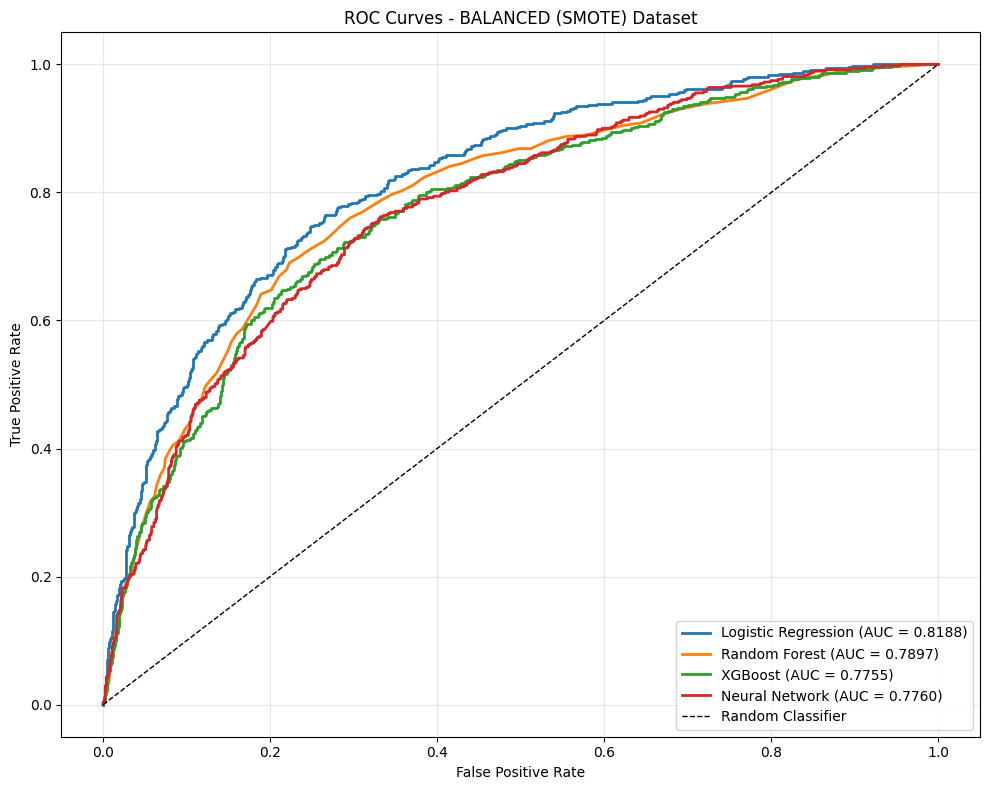


[PLOTTING] Confusion Matrices...


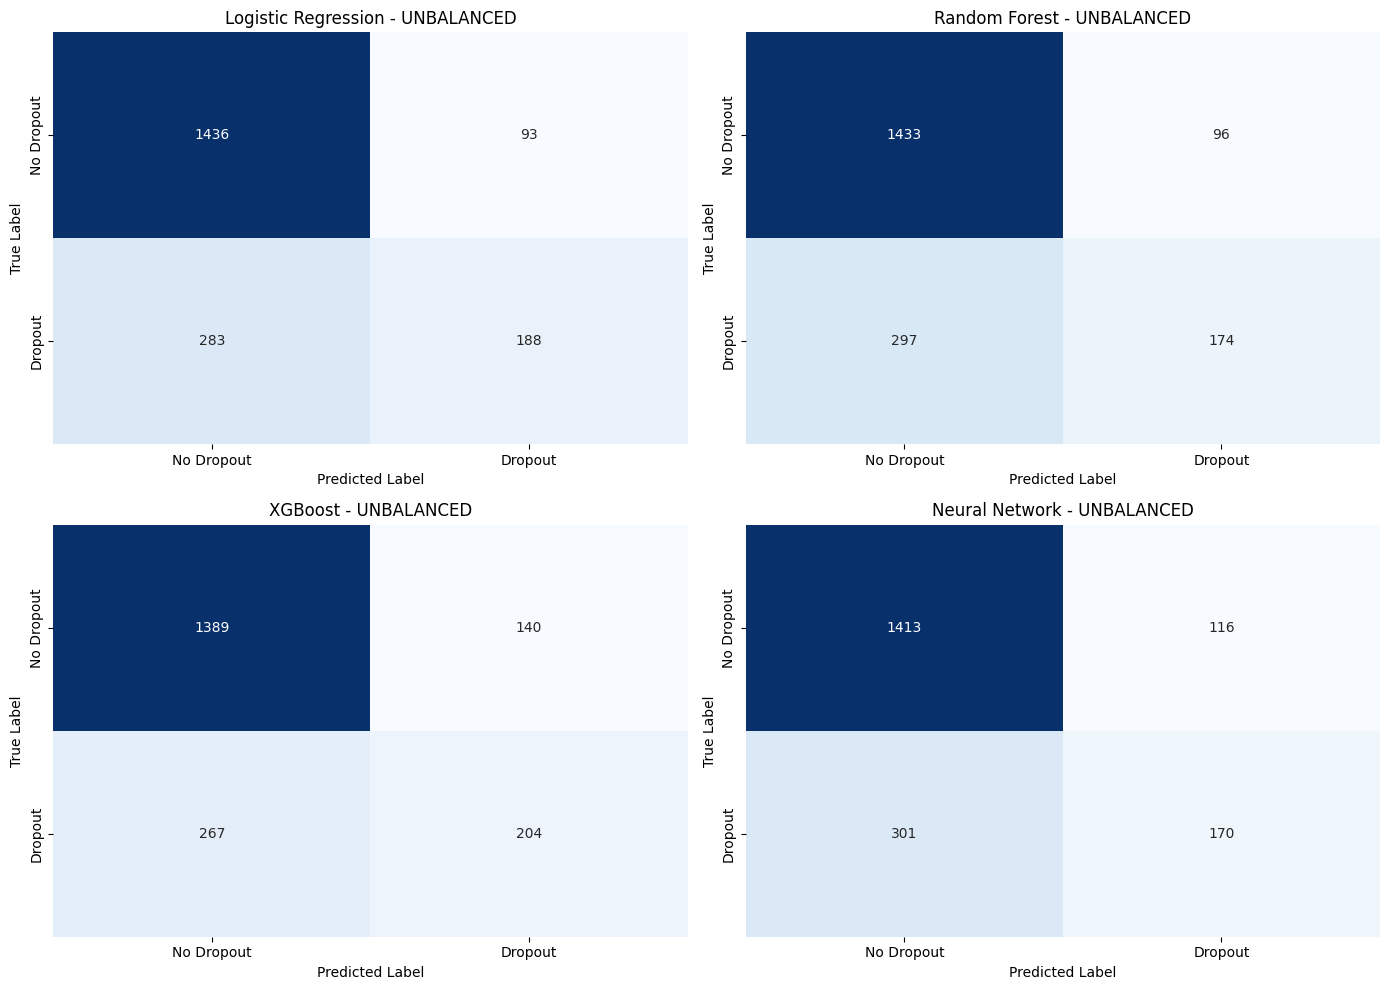

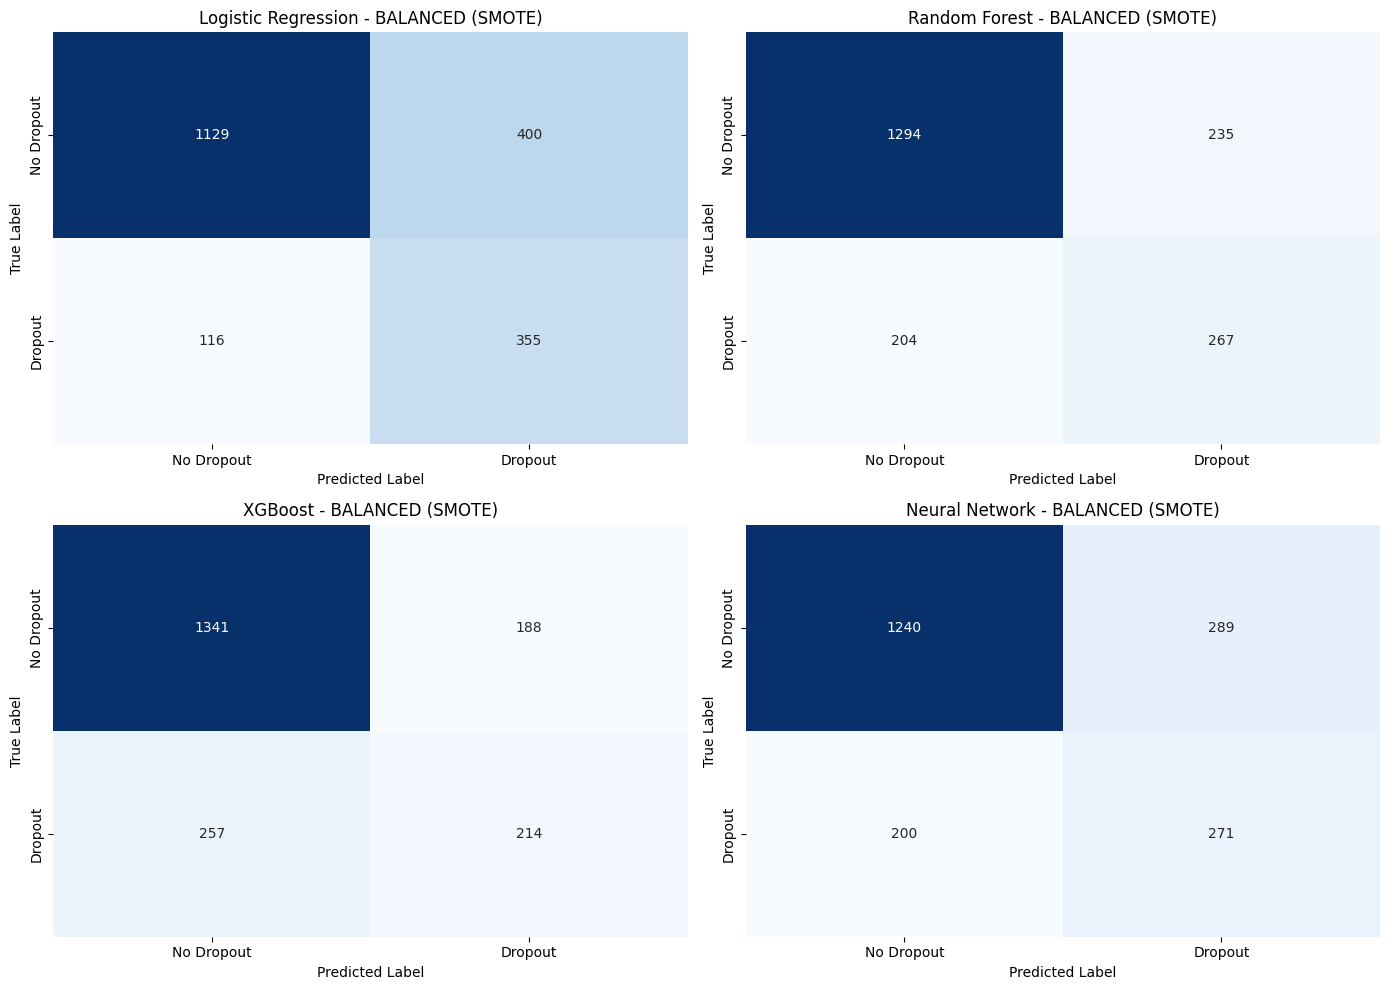

In [ ]:
print("\n[PLOTTING] ROC Curves...")
fig = plot_roc_curves(unbalanced_results, "UNBALANCED")
plt.savefig('roc_curves_unbalanced.png', dpi=300, bbox_inches='tight')
plt.show()

fig = plot_roc_curves(balanced_results, "BALANCED (SMOTE)")
plt.savefig('roc_curves_balanced.png', dpi=300, bbox_inches='tight')
plt.show()

# Confusion Matrices
print("\n[PLOTTING] Confusion Matrices...")
fig = plot_confusion_matrices(unbalanced_results, "UNBALANCED")
plt.savefig('confusion_matrices_unbalanced.png', dpi=300, bbox_inches='tight')
plt.show()

fig = plot_confusion_matrices(balanced_results, "BALANCED (SMOTE)")
plt.savefig('confusion_matrices_balanced.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
print("\n" + "█"*80)
print("█ PHASE 8: RESULTS COMPARISON & EXPORT")
print("█"*80)
print("\n[GENERATING] Comprehensive results comparison...")
comparison_df = create_results_comparison(unbalanced_results, balanced_results)

print("\n" + "="*80)
print("COMPREHENSIVE RESULTS COMPARISON")
print("="*80)
print(comparison_df.to_string(index=False))


████████████████████████████████████████████████████████████████████████████████
█ PHASE 8: RESULTS COMPARISON & EXPORT
████████████████████████████████████████████████████████████████████████████████

[GENERATING] Comprehensive results comparison...

COMPREHENSIVE RESULTS COMPARISON
              Model          Dataset Accuracy F1 Score Precision Recall ROC AUC Specificity
Logistic Regression       Unbalanced   0.8120   0.5000    0.6690 0.3992  0.8206      0.9392
Logistic Regression Balanced (SMOTE)   0.7420   0.5791    0.4702 0.7537  0.8188      0.7384
      Random Forest       Unbalanced   0.8035   0.4696    0.6444 0.3694  0.7994      0.9372
      Random Forest Balanced (SMOTE)   0.7805   0.5488    0.5319 0.5669  0.7897      0.8463
            XGBoost       Unbalanced   0.7965   0.5006    0.5930 0.4331  0.7763      0.9084
            XGBoost Balanced (SMOTE)   0.7775   0.4903    0.5323 0.4544  0.7755      0.8770
     Neural Network       Unbalanced   0.7915   0.4491    0.5944 0.360